# Chapter 3

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample, shuffle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


In [3]:
close = dollar_bars["price"].sort_index()

In [4]:
dollar_bars.shape

(1443691, 8)

### a. Apply a symmetric CUSUM filter (Chapter 2, Section 2.5.2.1) where the threshold is the standard deviation of daily returns (Snippet 3.1).

In [5]:
def get_daily_vol(close, span0=100):
    """Compute exponentially weighted daily return volatility."""
    close = close.sort_index()
    close = close[~close.index.duplicated(keep="last")]

    prev_pos = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    valid = prev_pos > 0

    current_pos = np.arange(len(close))[valid]
    prev_pos = prev_pos[valid] - 1

    returns = pd.Series(
        close.iloc[current_pos].to_numpy() / close.iloc[prev_pos].to_numpy() - 1,
        index=close.index[current_pos],
        name="daily_vol",
    )
    return returns.ewm(span=span0).std().dropna()

<Axes: xlabel='date'>

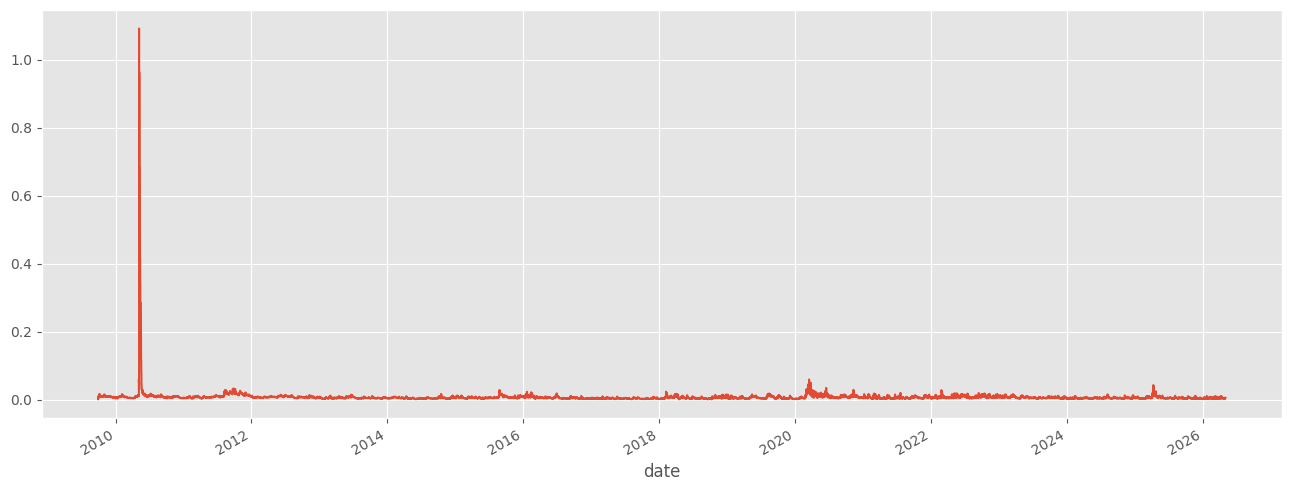

In [6]:
vols = get_daily_vol(close, span0=1000)
vols.plot()

In [7]:
vols.head()

date
2009-09-29 09:34:02    0.001322
2009-09-29 09:37:59    0.001165
2009-09-29 09:41:27    0.001765
2009-09-29 09:50:03    0.003447
2009-09-29 09:51:08    0.003727
Name: daily_vol, dtype: float64

In [8]:
def symmetric_cusum_filter(close, threshold):
    """Apply a symmetric CUSUM filter to log returns."""
    close = close.sort_index()
    log_ret = np.log(close).diff().dropna()

    if isinstance(threshold, pd.DataFrame):
        if threshold.shape[1] != 1:
            raise ValueError("threshold DataFrame must have exactly one column")
        threshold = threshold.iloc[:, 0]

    if isinstance(threshold, pd.Series):
        threshold_values = threshold.sort_index().reindex(log_ret.index).ffill().to_numpy()
    else:
        threshold_values = np.full(log_ret.shape[0], threshold)

    s_pos, s_neg = 0.0, 0.0
    t_events = []
    for t, ret, h in zip(log_ret.index, log_ret.to_numpy(), threshold_values):
        if pd.isna(h) or h <= 0:
            continue

        s_pos = max(0.0, s_pos + ret)
        s_neg = min(0.0, s_neg + ret)

        if s_pos > h:
            s_pos = 0.0
            t_events.append(t)
        elif s_neg < -h:
            s_neg = 0.0
            t_events.append(t)
    return pd.DatetimeIndex(t_events)


daily_vol = get_daily_vol(close, span0=1000)
t_events = symmetric_cusum_filter(close, daily_vol)
len(t_events), t_events[:5]

(9986,
 DatetimeIndex(['2009-09-29 09:34:02', '2009-09-29 09:41:27',
                '2009-09-29 09:59:17', '2009-09-29 10:00:15',
                '2009-09-29 10:16:16'],
               dtype='datetime64[us]', freq=None))

### b. Use Snippet 3.4 on a pandas series t1, where numDays = 1.

In [9]:
def get_vertical_bars(close, t_events, num_days=1):
    t1 = close.index.searchsorted(t_events + pd.Timedelta(days=num_days))
    t1 = t1[t1 < close.shape[0]]
    t1 = pd.Series(close.index[t1], index=t_events[:t1.shape[0]]) # NaNs at the end
    return t1

In [ ]:
vertical_bars = get_vertical_bars(close, t_events) # t1 in the text book
vertical_bars

2009-09-29 09:34:02   2009-09-30 09:34:37
2009-09-29 09:41:27   2009-09-30 09:42:11
2009-09-29 09:59:17   2009-09-30 10:00:08
2009-09-29 10:00:15   2009-09-30 10:00:50
2009-09-29 10:16:16   2009-09-30 10:17:02
                              ...        
2026-04-30 09:41:04   2026-05-01 09:41:36
2026-04-30 10:05:44   2026-05-01 10:05:47
2026-04-30 10:18:43   2026-05-01 10:19:09
2026-04-30 10:40:05   2026-05-01 10:40:10
2026-04-30 14:50:22   2026-05-01 14:51:58
Name: date, Length: 9984, dtype: datetime64[us]

### c. On those sampled features, apply the triple-barrier method, where ptSl = [1,1] and t1 is the series you created in point 1.b.

In [11]:
# TRIPLE-BARRIER LABELING METHOD
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """
    For example, from applied_pt_sl.csv:

    2010-05-06 14:46:25,2010-05-07 14:50:01,2010-05-06 14:48:37,2010-05-06 14:46:27
    For the event starting at 2010-05-06 14:46:25:

    vertical barrier: 2010-05-07 14:50:01
    stop loss touched: 2010-05-06 14:48:37
    profit taking touched: 2010-05-06 14:46:27
    
    Since pt happens first, the event should end at 2010-05-06 14:46:27.
    """
    """Apply stop loss on t1."""
    events_ = events.copy().loc[molecule]
    out = events_[['t1']].copy(deep=True)

    # upper limit (profit taking)
    if pt_sl[0] > 0:
        pt = pt_sl[0] * events_['target']
    else:
        pt = pd.Series(index=events.index) # NaNs
    
    # lower limit (stop loss)
    if pt_sl[1] > 0:
        sl = -pt_sl[1] * events_['target']
    else:
        sl = pd.Series(index=events.index) #  NaNs
    
    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        df0 = close[loc:t1_val] # path prices
        df0 = (df0 / close[loc] - 1) * events_.at[loc, 'side'] # path linear returns
        out.loc[loc, 'sl'] = df0[df0<sl[loc]].index.min() # earliest stop loss
        out.loc[loc, 'pt'] = df0[df0>pt[loc]].index.min() # earliest profit take

    
    # The output from this function is a pandas dataframe containing 
    # the timestamps (if any) at which each barrier was touched.
    return out

def get_events(close, t_events, pt_sl, target, min_ret, num_threads=1, t1=None, side=None):
    # Aligns target to t_events
    # Only events whose target is larger than min_ret are kept.
    target = target.loc[t_events]
    target = target[target > min_ret]
    if t1 is None:
        t1 = pd.Series(pd.NaT, index=t_events)
    
    if side is None:
        # default long side
        side_, pt_sl_ = pd.Series(1.0, index=target.index), [pt_sl[0], pt_sl[0]]
    else:
        side_, pt_sl_ = side.loc[target.index], pt_sl[:2]
    
    events = pd.concat({'t1': t1, 'target': target, 'side': side_}, axis=1).dropna(subset=['target'])
    barriers = mpPandasObj(func=apply_pt_sl_on_t1, pdObj=('molecule', events.index), numThreads=num_threads, close=close, events=events, pt_sl=pt_sl_)
    
    barriers.to_csv('applied_pt_sl.csv')
    # Replaces events['t1'] with the earliest touched barrier
    # However, we don't know which barrier is touched
    barriers = barriers.dropna(how='all')
    events['t1'] = barriers.min(axis=1)
    events['barrier'] = barriers.idxmin(axis=1)


    if side is None:
        events = events.drop('side', axis=1)
    
    return events

In [ ]:
abs_return = close.pct_change().abs()

events = get_events(close, t_events=t_events, pt_sl=[1,1], t1=vertical_bars, num_threads=1, target=abs_return, min_ret=0.01)

In [13]:
events

,t1,target,barrier
2009-10-02 09:29:12,2009-10-05 09:30:01,0.019608,t1
2009-10-14 09:29:46,2009-10-15 09:30:38,0.014448,t1
2009-11-23 09:30:00,2009-11-24 09:30:00,0.012316,t1
2009-11-27 09:30:04,2009-11-30 09:31:01,0.028878,t1
2009-12-01 09:33:28,2009-12-02 09:37:47,0.010962,t1
...,...,...,...
2026-01-20 09:30:00,2026-01-21 09:30:00,0.010080,t1
2026-03-03 09:30:00,2026-03-04 09:30:00,0.013366,t1
2026-04-07 18:32:29,2026-04-07 18:33:05,0.011183,sl
2026-04-07 18:33:05,2026-04-08 07:33:45,0.014095,pt


### d. Apply getBins to generate the labels.

In [14]:
def get_bins(events, close):
    events_ = events.dropna(subset=['t1'])

    px = events_.index.union(events_['t1'].values).drop_duplicates()
    px = close.reindex(px, method='bfill')

    out = pd.DataFrame(index=events_.index)
    out['ret'] = px.loc[events_['t1'].values].values / px.loc[events_.index] - 1
    if 'side' in events_:
        out['ret'] *= events_['side']  # meta-labeling


    out['bin'] = events_['barrier'].map({
        'pt': 1,
        'sl': -1,
        't1': 0,
    })
    
    if 'side' in events_:
        out.loc[out['ret'] <= 0, 'bin'] = 0
        out['side'] = events['side']

    return out

In [15]:
bins = get_bins(events, close)
bins

,ret,bin
2009-10-02 09:29:12,0.008765,0
2009-10-14 09:29:46,0.000190,0
2009-11-23 09:30:00,-0.000631,0
2009-11-27 09:30:04,0.013858,0
2009-12-01 09:33:28,0.002361,0
...,...,...
2026-01-20 09:30:00,-0.001674,0
2026-03-03 09:30:00,0.006694,0
2026-04-07 18:32:29,-0.014044,-1
2026-04-07 18:33:05,0.015278,1


In [16]:
value_counts = bins['bin'].value_counts()
print(f"Number of bin with 1: {value_counts.get(1, 0)}")
print(f"Number of bin with -1: {value_counts.get(-1, 0)}")
print(f"Number of bin with 0: {value_counts.get(0, 0)}")

Number of bin with 1: 74
Number of bin with -1: 80
Number of bin with 0: 226


## 2. From exercise 1, use Snippet 3.8 to drop rare labels.

In [17]:
def drop_labels(events, mitPct=0.05):
    # apply weights, drop labels with insufficient examples
    while True:
        df0 = events['bin'].value_counts(normalize=True)
        if df0.min() > mitPct or df0.shape[0] < 3:
            break
        print("Dropped label", df0.argmin(), df0.min())
        events = events[events['bin'] != df0.argmin()]
    return events

In [18]:
drop_labels(bins).head()

,ret,bin
2009-10-02 09:29:12,0.008765,0
2009-10-14 09:29:46,0.000190,0
2009-11-23 09:30:00,-0.000631,0
2009-11-27 09:30:04,0.013858,0
2009-12-01 09:33:28,0.002361,0


## 3. Adjust the getBins function (Snippet 3.5) to return a 0 whenever the vertical barrier is the one touched first.

In [19]:
# Already done in 1c

## 4. Develop a trend-following strategy based on a popular technical analysis statistic (e.g., crossing moving averages). For each observation, the model suggests a side, but not a size of the bet.

This section implements a basic trend-following trading strategy based on the moving average crossover technique, a popular method in technical analysis.

**Strategy Explanation:**

1. **Moving Averages Calculation**:
   - The strategy computes two moving averages of the closing price series:
     - A short-term moving average (`short_ma`) using a window of 50 time periods.
     - A long-term moving average (`long_ma`) using a window of 200 time periods.
   - The short-term moving average responds more sensitively to recent price changes, while the long-term average smooths out longer-term trends.

2. **Signal Generation**:
   - The trading signal is determined by the relationship between the two moving averages:
     - **Bullish Signal (1):** When the short-term moving average rises above the long-term moving average, it indicates upward momentum (a potential buy).
     - **Bearish Signal (-1):** When the short-term moving average falls below the long-term moving average, it signals downward momentum (a potential sell).
     - **Neutral Signal (0):** When both moving averages are equal, no position is suggested.

3. **Saving the Signals**:
   - The signals generated for each time period are stored in a pandas Series aligned to the original price index.
   - These signals are output to a CSV file (`trend_follow_signals.csv`) for later inspection or analysis.

This strategy does not decide on the position sizing ("how much to trade"), but only suggests the side of the bet (long, short, or neutral) for each observation.

In [20]:
# Trend-following strategy: moving average crossover
# 1. Compute short-term and long-term moving averages
short_window = 50
long_window = 200

short_ma = close.rolling(window=short_window, min_periods=1).mean()
long_ma = close.rolling(window=long_window, min_periods=1).mean()

# 2. Generate signals DataFrame with column name 'side'
signal = pd.DataFrame(index=close.index)
signal['side'] = 0
signal.loc[short_ma > long_ma, 'side'] = 1
signal.loc[short_ma < long_ma, 'side'] = -1

# Remove look-ahead bias by lagging the signal
signal['side'] = signal['side'].shift(1)

# 3. (Optional) Save or view the strategy signals
signal.to_csv("trend_follow_signals.csv")
signal.head()

,side
date,
2009-09-28 09:31:50,NaN
2009-09-28 09:33:02,0.0
2009-09-28 09:34:04,0.0
2009-09-28 09:38:28,0.0
2009-09-28 09:42:17,0.0


### a. Derive meta-labels for ptSl = [1,2] and t1 where numDays = 1. Use as trgt the daily standard deviation as computed by Snippet 3.1.

In [35]:
# reuse some results from the previous questions
events_new = get_events(close, t_events=t_events, pt_sl=[1,2], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01, side=signal['side'])
events_new.head()

,t1,target,side,barrier
2009-10-02 10:34:31,2009-10-05 09:30:01,0.010723,-1.0,t1
2009-10-05 14:56:12,2009-10-06 10:01:12,0.013587,1.0,pt
2009-10-06 09:54:55,2009-10-07 09:55:47,0.015873,1.0,t1
2009-10-08 09:29:16,2009-10-09 09:31:01,0.013587,1.0,t1
2009-10-12 09:29:50,2009-10-13 09:30:00,0.011173,1.0,t1


In [36]:
bins_new = get_bins(events_new, close) # meta labeling
print(bins_new.shape)
bins_new.head()

(1107, 3)


,ret,bin,side
2009-10-02 10:34:31,-0.000638,0,-1.0
2009-10-05 14:56:12,0.013837,1,1.0
2009-10-06 09:54:55,-0.004096,0,1.0
2009-10-08 09:29:16,-0.002128,0,1.0
2009-10-12 09:29:50,-0.004982,0,1.0


In [37]:
values_counts_new = bins_new['bin'].value_counts()
values_counts_new

bin
0    775
1    332
Name: count, dtype: int64

### b. Train a random forest to decide whether to trade or not. Note: The decision is whether to trade or not, {0,1}, since the underlying model (the crossing moving average) has decided the side, {−1,1}.

Create the following features:

* Volatility
* Serial Correlation
* The returns at the different lags from the serial correlation
* The sides from the SMavg Strategy

In [38]:
# Create initial features

# Log Returns
dollar_bars['log_ret'] = np.log(dollar_bars['price']).diff()
dollar_bars['log_t1'] = dollar_bars['log_ret'].shift(1)
# prevent look-ahead bias
shifted_price = dollar_bars['price'].shift(1)

# Momentum
dollar_bars['mom2'] = shifted_price.pct_change(periods=2)
dollar_bars['mom3'] = shifted_price.pct_change(periods=3)
dollar_bars['mom4'] = shifted_price.pct_change(periods=4)
dollar_bars['mom5'] = shifted_price.pct_change(periods=5)

# Volatility
dollar_bars['volatility_50'] = dollar_bars['log_t1'].rolling(window=50, min_periods=50, center=False).std()
dollar_bars['volatility_31'] = dollar_bars['log_t1'].rolling(window=31, min_periods=31, center=False).std()
dollar_bars['volatility_15'] = dollar_bars['log_t1'].rolling(window=15, min_periods=15, center=False).std()

# Serial Correlation (Takes about 4 minutes)
window_autocorr = 50

dollar_bars['autocorr_1'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=1), raw=False)
dollar_bars['autocorr_2'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=2), raw=False)
dollar_bars['autocorr_3'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=3), raw=False)
dollar_bars['autocorr_4'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=4), raw=False)
dollar_bars['autocorr_5'] = dollar_bars['log_t1'].rolling(window=window_autocorr, min_periods=window_autocorr, center=False).apply(lambda x: x.autocorr(lag=5), raw=False)

# Get the various log -t returns
dollar_bars['log_t2'] = dollar_bars['log_ret'].shift(2)
dollar_bars['log_t3'] = dollar_bars['log_ret'].shift(3)
dollar_bars['log_t4'] = dollar_bars['log_ret'].shift(4)
dollar_bars['log_t5'] = dollar_bars['log_ret'].shift(5)

In [93]:
# prepare train and test data
# Get features at event dates
feature_cols = ["volatility_50", "volatility_31", "volatility_15", "autocorr_1", "autocorr_2", "autocorr_3", "autocorr_4", "autocorr_5", "log_t1", "log_t2", "log_t3", "log_t4", "log_t5", "mom2", "mom3", "mom4", "mom5"]
X = dollar_bars.loc[bins_new.index, feature_cols].copy()
X['side'] = bins_new['side']
y = bins_new['bin']

In [94]:
X.head()

,volatility_50,volatility_31,volatility_15,autocorr_1,autocorr_2,autocorr_3,autocorr_4,autocorr_5,log_t1,log_t2,log_t3,log_t4,log_t5,mom2,mom3,mom4,mom5,side
2009-10-02 10:34:31,0.000826,0.000837,0.000827,0.011851,-0.246314,-0.009116,0.108219,0.041387,0.001409,0.000941,-0.000202,0.000125,-0.000057,0.002353,0.002151,0.002276,0.002218,-1.0
2009-10-05 14:56:12,0.000497,0.000451,0.000354,-0.090065,0.183872,-0.194370,0.190849,0.036812,0.000107,0.000053,0.000602,0.000426,0.000404,0.000160,0.000763,0.001190,0.001595,1.0
2009-10-06 09:54:55,0.001384,0.001724,0.002343,-0.174543,0.188635,0.059918,-0.000720,0.068728,-0.000977,0.001172,-0.000528,0.002093,0.001558,0.000196,-0.000332,0.001762,0.003324,1.0
2009-10-08 09:29:16,0.000399,0.000318,0.000308,-0.222676,-0.010991,-0.021742,0.006978,-0.272798,0.000139,-0.000585,0.000000,0.000211,-0.000016,-0.000447,-0.000447,-0.000235,-0.000252,1.0
2009-10-12 09:29:50,0.000377,0.000334,0.000270,-0.184780,0.139600,-0.021010,-0.040162,0.362673,0.000339,0.000244,0.000720,0.000193,0.000029,0.000583,0.001304,0.001497,0.001526,1.0


In [95]:
# The final train/test split is chronological, which is good, 
# but you should purge boundary overlap:
# Otherwise a training label near the split can use future price movement inside the test period.
test_start = pd.Timestamp('2024-01-01')
train_idx = (X.index < test_start) & (events_new.loc[X.index, 't1'] < test_start)

X_train = X[train_idx]
X_test = X[~train_idx]
y_train = y[train_idx]
y_test = y[~train_idx]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1055, 18)
X_test shape: (52, 18)
y_train shape: (1055,)
y_test shape: (52,)


In [96]:
parameters = {'max_depth':[2, 3, 4, 5, 7],
              'n_estimators':[1, 10, 25, 50, 100, 256, 512],
              'random_state':[42]}
    
def perform_grid_search(X_data, y_data):
    rf = RandomForestClassifier(criterion='entropy')
    
    clf = GridSearchCV(rf, parameters, cv=4, scoring='roc_auc', n_jobs=3)
    
    clf.fit(X_data, y_data)
    
    print(clf.cv_results_['mean_test_score'])
    
    return clf.best_params_['n_estimators'], clf.best_params_['max_depth']

In [97]:
# extract parameters
best_estimator, best_depth = perform_grid_search(X_train, y_train)
c_random_state = 42
print(best_estimator, best_depth, c_random_state)

[0.50725352 0.52103273 0.5338457  0.54203538 0.55052368 0.54793607
 0.54676377 0.5153858  0.52349442 0.53392616 0.53211811 0.53707663
 0.53595119 0.54090952 0.51259952 0.51971903 0.52178473 0.53576953
 0.53302174 0.52830484 0.53007296 0.49007339 0.52409939 0.51115162
 0.51354549 0.51983184 0.52723481 0.52439693 0.50243022 0.51663461
 0.5211422  0.51974213 0.50877914 0.51869385 0.52005924]
100 2 42


In [98]:
# Refit a new model with best params, so we can see feature importance
rf = RandomForestClassifier(max_depth=best_depth, n_estimators=best_estimator,
                            criterion='entropy', random_state=c_random_state)

rf.fit(X_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       0.69      1.00      0.82        36
           1       0.00      0.00      0.00        16

    accuracy                           0.69        52
   macro avg       0.35      0.50      0.41        52
weighted avg       0.48      0.69      0.57        52

Confusion Matrix
[[36  0]
 [16  0]]

Accuracy
0.6923076923076923


/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

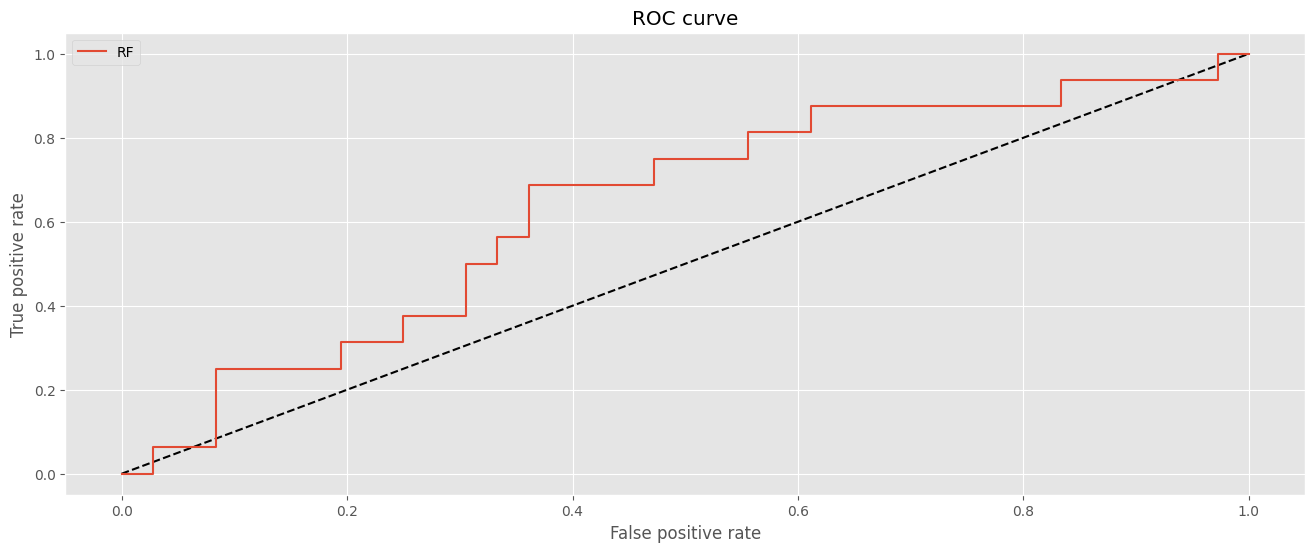

In [99]:
# Performance Metrics
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test.values.ravel(), y_pred_rf)
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print('')
print("Accuracy")
print(accuracy_score(y_test, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

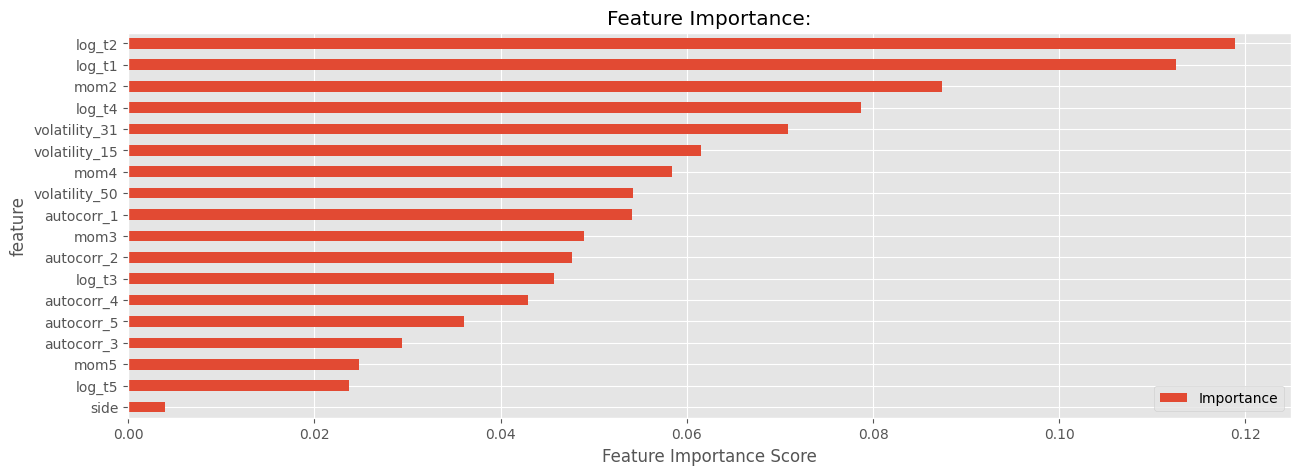

In [100]:
# Feature Importance
title = 'Feature Importance:'
figsize = (15, 5)

feat_imp = pd.DataFrame({'Importance':rf.feature_importances_})    
feat_imp['feature'] = X.columns
feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
feat_imp = feat_imp

feat_imp.sort_values(by='Importance', inplace=True)
feat_imp = feat_imp.set_index('feature', drop=True)
feat_imp.plot.barh(title=title, figsize=figsize)
plt.xlabel('Feature Importance Score')
plt.show()

## 5. Develop a mean-reverting strategy based on Bollinger bands. For each observation, the model suggests a side, but not a size of the bet.

In [101]:
# 5. Develop a mean-reverting strategy based on Bollinger bands.
# For each observation, the model suggests a side, but not a size of the bet.

# Calculate Bollinger Bands
window = 10000  # typical Bollinger Bands window
n_std = 2    # number of standard deviations

rolling_mean = close.rolling(window=window, min_periods=1).mean()
rolling_std = close.rolling(window=window, min_periods=1).std()

upper_band = rolling_mean + (rolling_std * n_std)
lower_band = rolling_mean - (rolling_std * n_std)

# Create signal DataFrame to store trade signals (side: 1=long, -1=short, 0=no position)
bollinger_signal = pd.DataFrame(index=close.index)
bollinger_signal['price'] = close

# Long (mean-reverting) when price hits (or dips below) lower band
bollinger_signal['side'] = pd.NA  # Default
bollinger_signal.loc[close <= lower_band, 'side'] = 1  # Long (expect up revert)
# Short (mean-reverting) when price hits (or exceeds) upper band
bollinger_signal.loc[close >= upper_band, 'side'] = -1 # Short (expect down revert)
bollinger_signal['side'] = bollinger_signal['side'].ffill() # long until we're short

bollinger_signal['upper_band'] = upper_band
bollinger_signal['lower_band'] = lower_band
bollinger_signal['rolling_mean'] = rolling_mean

# Drop rows with no signal if desired, or keep all for further processing
bollinger_signal.head()

,price,side,upper_band,lower_band,rolling_mean
date,,,,,
2009-09-28 09:31:50,50.75,<NA>,NaN,NaN,50.750000
2009-09-28 09:33:02,50.81,<NA>,50.864853,50.695147,50.780000
2009-09-28 09:34:04,50.82,<NA>,50.869052,50.717615,50.793333
2009-09-28 09:38:28,50.81,<NA>,50.861531,50.733469,50.797500
2009-09-28 09:42:17,50.85,<NA>,50.880664,50.735336,50.808000


In [102]:
bollinger_signal.side.value_counts()

side
-1    852142
1     591301
Name: count, dtype: int64

### a. Derive meta-labels for ptSl = [0,2] and t1 where numDays = 1. Use as trgt the daily standard deviation as computed by Snippet 3.1.

In [103]:
# reuse some results from the previous questions
events_mean_reverting = get_events(close, t_events=t_events, pt_sl=[0,2], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01, side=bollinger_signal['side'])
events_mean_reverting.head()

,t1,target,side,barrier
2009-10-02 10:34:31,2009-10-05 09:30:01,0.010723,1,t1
2009-10-05 14:56:12,2009-10-06 15:01:52,0.013587,1,t1
2009-10-06 09:54:55,2009-10-07 09:55:47,0.015873,1,t1
2009-10-08 09:29:16,2009-10-09 09:31:01,0.013587,1,t1
2009-10-12 09:29:50,2009-10-13 09:30:00,0.011173,1,t1


In [104]:
bins_mean_reverting = get_bins(events_mean_reverting, close) # meta labeling
print(bins_mean_reverting.shape)
bins_mean_reverting.head()

(1107, 3)


,ret,bin,side
2009-10-02 10:34:31,0.000638,0,1
2009-10-05 14:56:12,0.007314,0,1
2009-10-06 09:54:55,-0.004096,0,1
2009-10-08 09:29:16,-0.002128,0,1
2009-10-12 09:29:50,-0.004982,0,1


In [105]:
values_counts_mean_reverting = bins_mean_reverting['bin'].value_counts()
values_counts_mean_reverting

bin
0    1107
Name: count, dtype: int64

### b. Train a random forest to decide whether to trade or not. Use as features: volatility, serial correlation, and the crossing moving averages from exercise 2.

In [106]:
# add crossing moving average as features to dollar bars
dollar_bars['short_ma'] = close.rolling(window=short_window, min_periods=1).mean()
dollar_bars['long_ma'] = close.rolling(window=long_window, min_periods=1).mean()
dollar_bars['short_ma_cross_long_ma'] = (dollar_bars['short_ma'] > dollar_bars['long_ma']).astype(int)
dollar_bars['long_ma_cross_short_ma'] = (dollar_bars['long_ma'] > dollar_bars['short_ma']).astype(int)

In [107]:
# prepare train and test data
# Get features at event dates
feature_cols_2 = ["volatility_50", "volatility_31", "volatility_15", "autocorr_1", "autocorr_2", "autocorr_3", "autocorr_4", "autocorr_5", "short_ma_cross_long_ma", "long_ma_cross_short_ma"]
X = dollar_bars.loc[bins_new.index, feature_cols_2].copy()
X['side'] = bins_new['side']
y = bins_new['bin']

# The final train/test split is chronological, which is good, 
# but you should purge boundary overlap:
# Otherwise a training label near the split can use future price movement inside the test period.
test_start = pd.Timestamp('2025-01-01')
train_idx = (X.index < test_start) & (events_new.loc[X.index, 't1'] < test_start)

X_train = X[train_idx]
X_test = X[~train_idx]
y_train = y[train_idx]
y_test = y[~train_idx]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1061, 11)
X_test shape: (46, 11)
y_train shape: (1061,)
y_test shape: (46,)


In [108]:
parameters = {'max_depth':[2, 3, 4, 5, 7],
              'n_estimators':[1, 10, 25, 50, 100, 256, 512],
              'random_state':[42]}
    
def perform_grid_search(X_data, y_data):
    rf = RandomForestClassifier(criterion='entropy')
    
    clf = GridSearchCV(rf, parameters, cv=4, scoring='roc_auc', n_jobs=3)
    
    clf.fit(X_data, y_data)
    
    print(clf.cv_results_['mean_test_score'])
    
    return clf.best_params_['n_estimators'], clf.best_params_['max_depth']

# extract parameters
best_estimator, best_depth = perform_grid_search(X_train, y_train)
c_random_state = 42
print(best_estimator, best_depth, c_random_state)

[0.50763772 0.52048537 0.52214467 0.52791738 0.52776448 0.53054095
 0.53173855 0.50967191 0.52840945 0.52011866 0.52503304 0.51956171
 0.5250587  0.5262463  0.4924862  0.52306559 0.52752024 0.53083814
 0.52352865 0.51712001 0.5184439  0.49168515 0.52674497 0.52996371
 0.5235735  0.51652763 0.5141134  0.51042251 0.50310287 0.52419482
 0.5146088  0.50532958 0.50125174 0.50245053 0.50354341]
512 2 42


In [109]:
# Refit a new model with best params, so we can see feature importance
rf = RandomForestClassifier(max_depth=best_depth, n_estimators=best_estimator,
                            criterion='entropy', random_state=c_random_state)

rf.fit(X_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",512
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        30
           1       0.00      0.00      0.00        16

    accuracy                           0.65        46
   macro avg       0.33      0.50      0.39        46
weighted avg       0.43      0.65      0.51        46

Confusion Matrix
[[30  0]
 [16  0]]

Accuracy
0.6521739130434783


/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

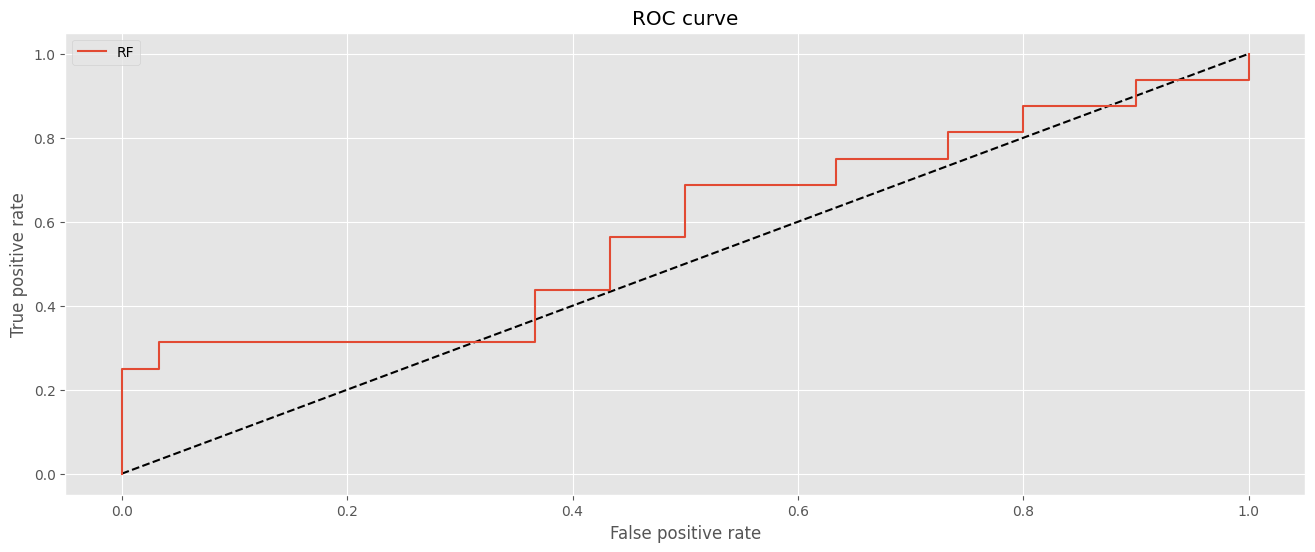

In [110]:
# Performance Metrics
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test.values.ravel(), y_pred_rf)
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print('')
print("Accuracy")
print(accuracy_score(y_test, y_pred))

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

### c. What is the accuracy of predictions from the primary model (i.e., if the secondary model does not filter the bets)? What are the precision, recall, and F1-scores?